<a href="https://colab.research.google.com/github/Zee5h4n/lessons-learned/blob/Animal-Classification-CRNN/AnimalClassficationCRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ANIMAL CLASSFICATION BY USING CRNN**

In [21]:
#Import libriries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report
from PIL import Image
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
import random



In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
zip_path = "/content/drive/MyDrive/Colab Notebooks/Animalfinal.zip"
print("Zip exists:", os.path.exists(zip_path))


Zip exists: True


In [4]:
zip_path = "/content/drive/MyDrive/Colab Notebooks/Animalfinal.zip"
extract_path = '/content/plant_disease_data'

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Extract zip file
print("Extracting ZIP file...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Files extracted to: {extract_path}")

Extracting ZIP file...
Files extracted to: /content/plant_disease_data


In [5]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:
        print(f'{subindent}{file}')
    if len(files) > 3:
        print(f'{subindent}... and {len(files)-3} more files')

plant_disease_data/
  afhq/
    train/
      dog/
        pixabay_dog_000125.jpg
        flickr_dog_000913.jpg
        flickr_dog_000336.jpg
        ... and 4736 more files
      cat/
        pixabay_cat_003168.jpg
        pixabay_cat_000513.jpg
        pixabay_cat_000255.jpg
        ... and 5150 more files
      wild/
        pixabay_wild_000495.jpg
        flickr_wild_003410.jpg
        flickr_wild_001443.jpg
        ... and 4735 more files
    val/
      dog/
        pixabay_dog_002739.jpg
        flickr_dog_000854.jpg
        pixabay_dog_000017.jpg
        ... and 497 more files
      cat/
        flickr_cat_000387.jpg
        pixabay_cat_003804.jpg
        pixabay_cat_004596.jpg
        ... and 497 more files
      wild/
        flickr_wild_000568.jpg
        flickr_wild_002182.jpg
        flickr_wild_003145.jpg
        ... and 497 more files


In [6]:
#image transformation
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


In [7]:
BASE_DIR = "/content/plant_disease_data/afhq"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Val exists:", os.path.exists(VAL_DIR))

Train exists: True
Val exists: True


In [8]:
#Load Datasets
train_data = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_data   = datasets.ImageFolder(VAL_DIR, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader  = DataLoader(val_data, batch_size=16, shuffle=False)

class_names = train_data.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Total classes:", num_classes)


Classes: ['cat', 'dog', 'wild']
Total classes: 3


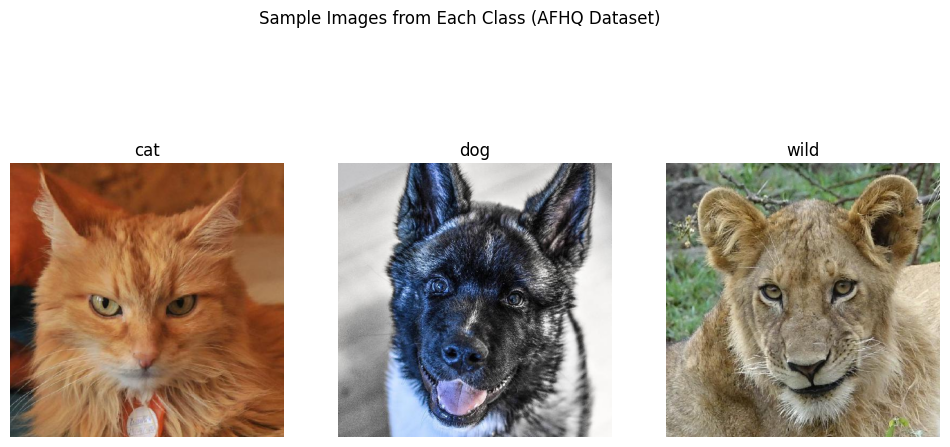

In [25]:
plt.figure(figsize=(12, 6))

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(TRAIN_DIR, class_name)
    images = os.listdir(class_path)

    img_path = os.path.join(class_path, random.choice(images))
    img = Image.open(img_path)

    plt.subplot(1, len(class_names), idx + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Sample Images from Each Class (AFHQ Dataset)")
plt.show()


In [9]:
#CRNN Model
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()

        # CNN
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # RNN
        self.rnn = nn.LSTM(
            input_size=64 * 32,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        # Fully Connected
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        b, c, h, w = x.size()

        x = x.permute(0, 3, 1, 2)      # (B, W, C, H)
        x = x.reshape(b, w, c * h)

        rnn_out, _ = self.rnn(x)
        out = self.fc(rnn_out[:, -1, :])
        return out


In [10]:
#Model Initialize
model = CRNN(num_classes)

In [11]:
#loss
criterion = nn.CrossEntropyLoss()

In [12]:
#Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)

CRNN(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (rnn): LSTM(2048, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [16]:
model.to(device)
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10] Loss: 0.8806
Epoch [2/10] Loss: 0.3897
Epoch [3/10] Loss: 0.2126
Epoch [4/10] Loss: 0.1500
Epoch [5/10] Loss: 0.1157
Epoch [6/10] Loss: 0.0925
Epoch [7/10] Loss: 0.0784
Epoch [8/10] Loss: 0.0669
Epoch [9/10] Loss: 0.0549
Epoch [10/10] Loss: 0.0462


In [17]:
#Evaluation
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))


Accuracy: 0.9693333333333334
              precision    recall  f1-score   support

         cat       0.99      0.96      0.97       500
         dog       0.95      0.97      0.96       500
        wild       0.97      0.97      0.97       500

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500



In [18]:
# Save Model to Drive
MODEL_PATH = "/content/drive/MyDrive/afhq_crnn_model.pth"
torch.save(model.state_dict(), MODEL_PATH)

print("Model saved at:", MODEL_PATH)


Model saved at: /content/drive/MyDrive/afhq_crnn_model.pth


In [22]:
# Single Image Prediction
def predict_image(image_path):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return class_names[pred.item()]


In [24]:
predict_image

<function __main__.predict_image(image_path)>